In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/11010
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  10894.450671872324
RUN  2 , total integrated cost =  10844.827779895359
RUN  3 , total integrated cost =  10839.440049596187
RUN  4 , total integrated cost =  10839.436695762766
RUN  5 , total integrated cost =  10839.436695762764
RUN  6 , total integrated cost =  10839.436695762763


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  10839.436695762763
Control only changes marginally.
RUN  7 , total integrated cost =  10839.436695762763
Improved over  7  iterations in  17.632654704153538  seconds by  18.570491701351415  percent.
Problem in initial value trasfer:  Vmean_exc -56.65566694584334 -56.656121578995446
weight =  12.28056046135546
set cost params:  1.0 12.28056046135546 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11018.923571281844
Gradient descend method:  None
RUN  1 , total integrated cost =  11010.281689201533
RUN  2 , total integrated cost =  11010.273805719202
RUN  3 , total integrated cost =  11010.273805502991
RUN  4 , total integrated cost =  11010.27380550299
RUN  5 , total integrated cost =  11010.27380550299
Control only changes marginally.
RUN  5 , total integrated cost =  11010.27380550299
Improved over  5  iterations in  0.18572362326085567  seconds by  0.07849919026027408  percent.
Problem in initial value trasfer:  Vmean_exc 

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  19289.651052684345
Control only changes marginally.
RUN  22 , total integrated cost =  19289.65105268434
Improved over  22  iterations in  0.860622514039278  seconds by  10.551856233536512  percent.
Problem in initial value trasfer:  Vmean_exc -56.69301162517598 -56.69326748409181
weight =  11.179661845312957
set cost params:  1.0 11.179661845312957 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19376.14110732475
Gradient descend method:  None
RUN  1 , total integrated cost =  19376.12031594304
RUN  2 , total integrated cost =  19376.119331548085
RUN  3 , total integrated cost =  19376.11931087936
RUN  4 , total integrated cost =  19376.119310879356


...

RUN  2 , total integrated cost =  9543.986181556998
RUN  3 , total integrated cost =  9543.986181556998
Control only changes marginally.
RUN  3 , total integrated cost =  9543.986181556998
Improved over  3  iterations in  0.1721219513565302  seconds by  7.105427357601002e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.647340950083944 -56.64747059658806
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768838654094
Gradient descend method:  None
RUN  1 , total integrated cost =  22767.559136680706
RUN  2 , total integrated cost =  22763.752901018164
RUN  3 , total integrated cost =  22763.297973028813
RUN  4 , total integrated cost =  22763.055050820305
RUN  5 , total integrated cost =  22761.97595357461
RUN  6 , total integrated cost =  22761.435135257834
RUN  7 , total integrated cost =  22761.17490915869
RUN  8 , total integrated cost =  22760.962937387885
RUN 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  106 , total integrated cost =  22758.427953621765
Improved over  106  iterations in  4.193485056981444  seconds by  2.8694785461890575  percent.
Problem in initial value trasfer:  Vmean_exc -56.69962685962619 -56.69968563892792
weight =  10.295425011957091
set cost params:  1.0 10.295425011957091 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22767.475781324392
Gradient descend method:  None
RUN  1 , total integrated cost =  22767.47578132439


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  22767.47578132439
Control only changes marginally.
RUN  2 , total integrated cost =  22767.47578132439
Improved over  2  iterations in  0.22065987437963486  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.69962685962619 -56.69968563892792


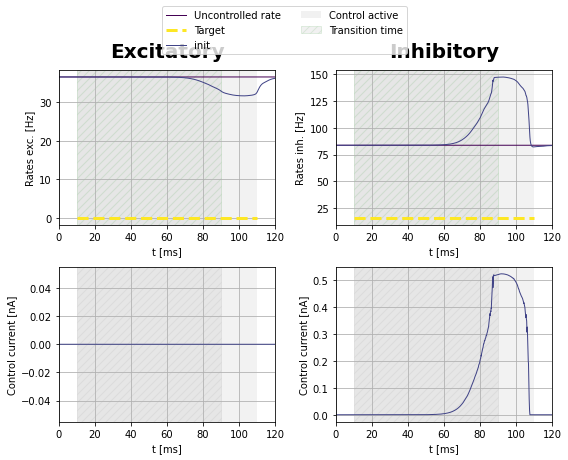

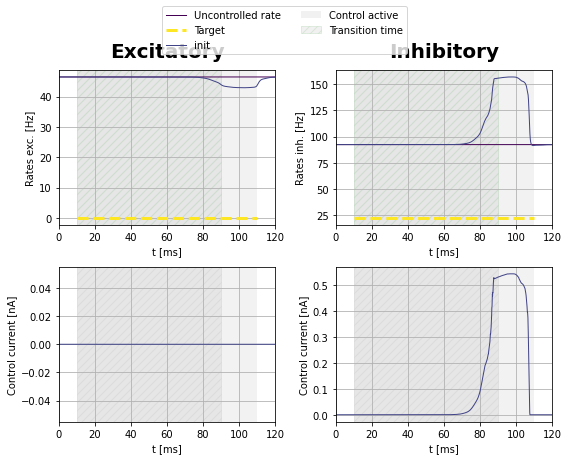

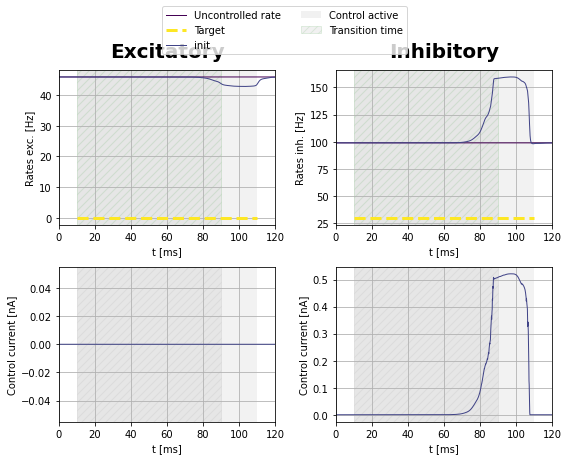

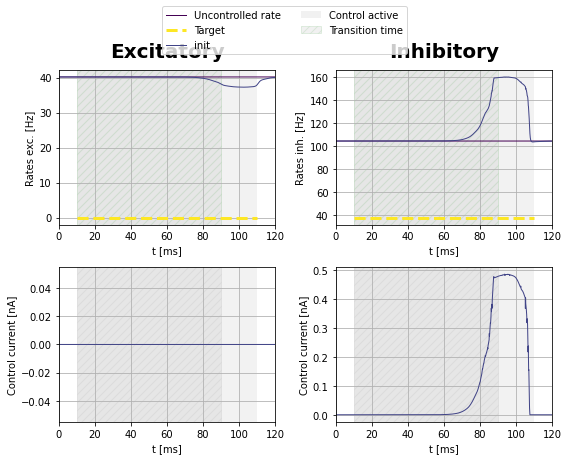

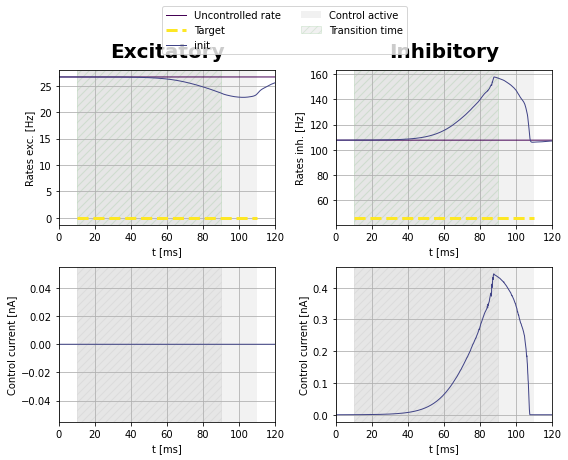

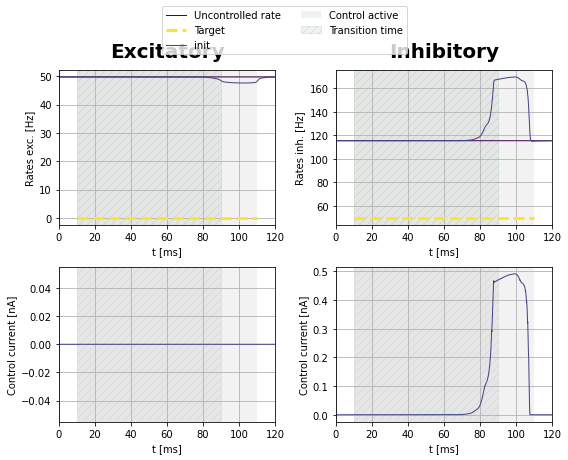

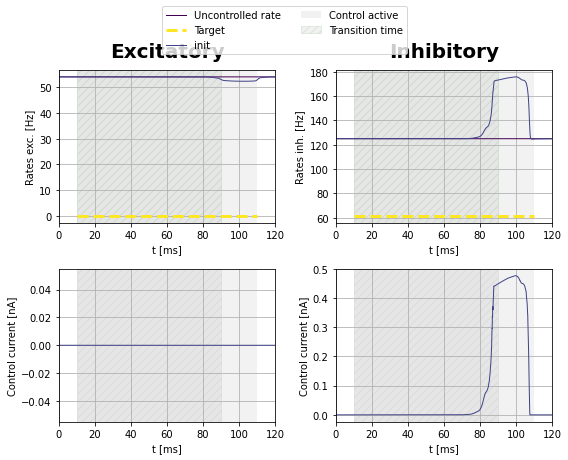

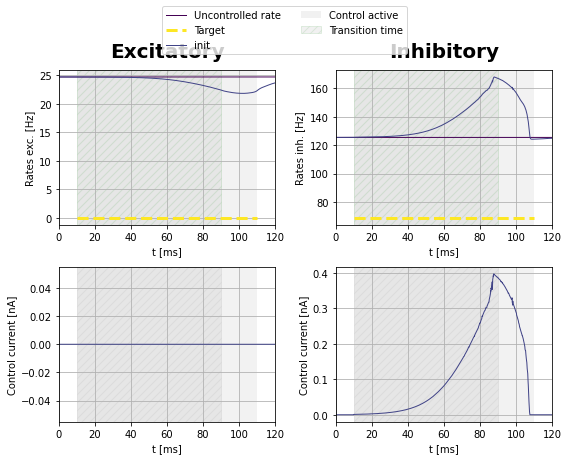

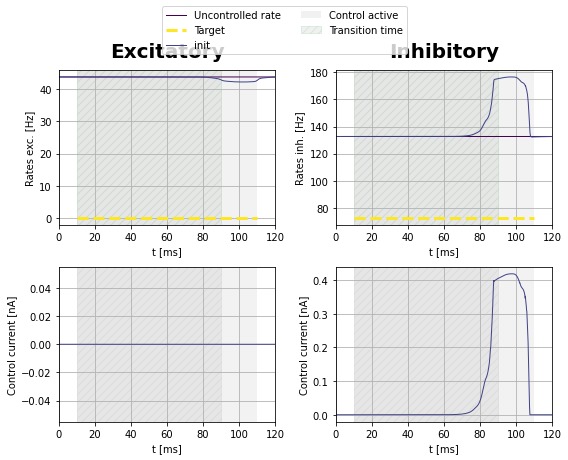

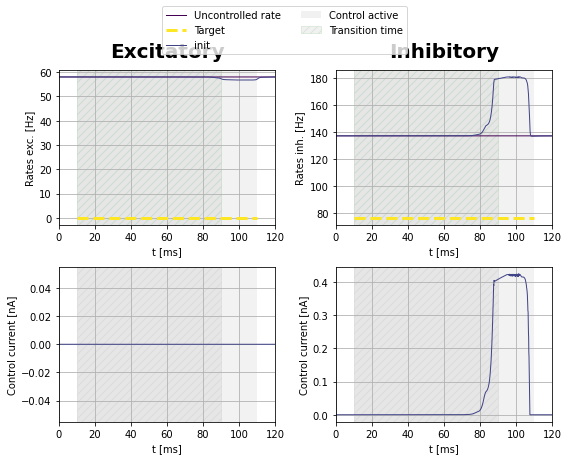

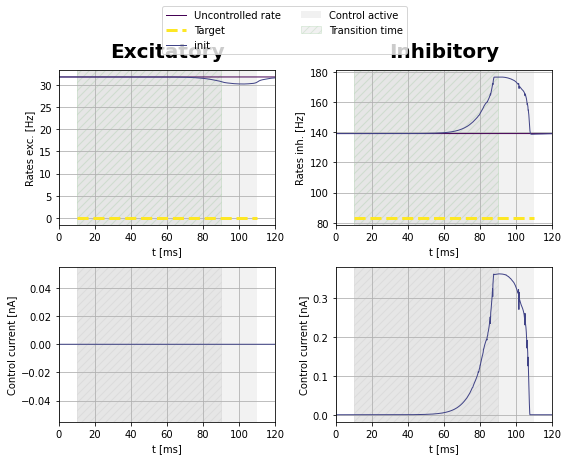

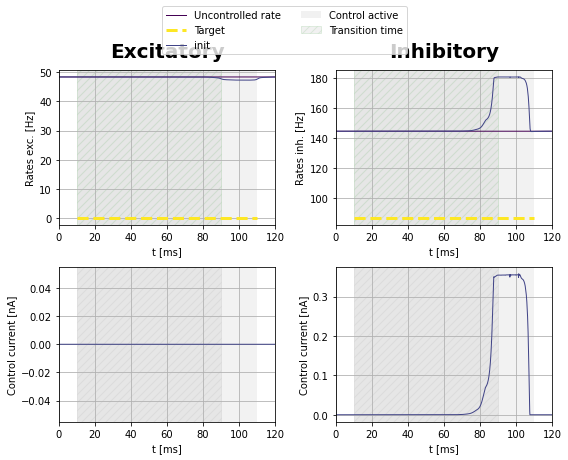

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
no solutions found
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  11 0.4500000000000001 0.42500000000000016
no solutions found
closest inde

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  552.7147076087895
set cost params:  1.0 552.7147076087895 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5550.463288670641
Gradient descend method:  None
RUN  1 , total integrated cost =  5549.357221966452
RUN  2 , total integrated cost =  5549.356149905879
RUN  3 , total integrated cost =  5549.356148574086
RUN  4 , total integrated cost =  5549.356148574083
RUN  5 , total integrated cost =  5549.356148574081
RUN  6 , total integrated cost =  5549.356148574079


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  5549.356148574079
Control only changes marginally.
RUN  7 , total integrated cost =  5549.356148574079
Improved over  7  iterations in  0.3707063850015402  seconds by  0.01994680514006575  percent.
Problem in initial value trasfer:  Vmean_exc -56.625836903480305 -56.62586893773399
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  13.847214038465838
set cost params:  1.0 13.847214038465838 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11117.469618390372
Gradient descend method:  None
RUN  1 , total integrated cost =  11111.075552748485
RUN  2 , total integrated cost =  11111.069681581535
RUN  3 , total integrated cost =  11111.069651808248
RUN  4 , total integrated cost =  11111.069651790416
RUN  5 , total integrated cost =  11111.069651790413
RUN  6 , total integrated cost =  11111.06965179041


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  11111.069651790407
RUN  8 , total integrated cost =  11111.069651790407
Control only changes marginally.
RUN  8 , total integrated cost =  11111.069651790407
Improved over  8  iterations in  0.3722113575786352  seconds by  0.057566755922394464  percent.
Problem in initial value trasfer:  Vmean_exc -56.65704091001308 -56.65747030393611
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  11.442707912933548
set cost params:  1.0 11.442707912933548 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19395.2676559605
Gradient descend method:  None
RUN  1 , total integrated cost =  19395.023704638013
RUN  2 , total integrated cost =  19395.023461065466
RUN  3 , total integrated cost =  19395.023461065462


...

Control only changes marginally.
RUN  37 , total integrated cost =  18140.18364310639
Improved over  37  iterations in  1.5025260876864195  seconds by  0.0018792553221231856  percent.
Problem in initial value trasfer:  Vmean_exc -56.690313343530576 -56.69044904610333
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  3.394795216111457
set cost params:  1.0 3.394795216111457 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32391.518110370962
Gradient descend method:  None
RUN  1 , total integrated cost =  32391.504571906884
RUN  2 , total integrated cost =  32391.491776171137
RUN  3 , total integrated cost =  32391.480750175724
RUN  4 , total integrated cost =  32391.473579491154
RUN  5 , total integrated cost =  32391.46579318841
RUN  6 , total integrated cost =  32391.45492479091
RUN  7 , total integrated cost =  32391.450807425965
RUN  8 , total integrated cost =  32391.435161314428
RUN  9 , total integrated cost =  32391.4332527830

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  32391.414739182615
Control only changes marginally.
RUN  15 , total integrated cost =  32391.414739182615
Improved over  15  iterations in  0.671323124319315  seconds by  0.00031913042171538564  percent.
Problem in initial value trasfer:  Vmean_exc -56.703790585431776 -56.70377753169081
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
no convergence
weight =  3.4563426646147146
set cost params:  1.0 3.4563426646147146 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22549.43343993478
Gradient descend method:  None
RUN  1 , total integrated cost =  22549.423301652787
RUN  2 , total integrated cost =  22549.4095744801
RUN  3 , total integrated cost =  22549.40717956743
RUN  4 , total integrated cost =  22549.385515698705
RUN  5 , total integrated cost =  22549.38398840498
RUN  6 , total integrated cost =  22549.36344488899
RUN  7 , total integrated cost = 

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  22549.363259817554
Control only changes marginally.
RUN  10 , total integrated cost =  22549.363259817554
Improved over  10  iterations in  0.4548285510390997  seconds by  0.0003112278515260414  percent.
Problem in initial value trasfer:  Vmean_exc -56.69956690408286 -56.69962954200535


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11126.170574941912
Gradient descend method:  None
RUN  1 , total integrated cost =  151.7467104497438
RUN  2 , total integrated cost =  79.18136936264254
RUN  3 , total integrated cost =  59.86195027412635
RUN  4 , total integrated cost =  53.78114404814541
RUN  5 , total integrated cost =  47.000724223539784
RUN  6 , total integrated cost =  43.404120888007306
RUN  7 , total integrated cost =  40.32230000319716
RUN  8 , total integrated cost =  37.13177351965654
RUN  9 , total integrated cost =  35.067147875962554
RUN  10 , total integrated cost =  32.12994144417636
RUN  11 , total integrated cost =  31.042235421200544
RUN  12 , total integrated cost =  30.9729759669975
RUN  13 , total integrated cost =  30.592626885128727
RUN  14 , total integrated cost =  30.370247643029394
RUN  15 , total integrated cost =  30.247085137901205
RUN 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  56 , total integrated cost =  25.33369678165192
Improved over  56  iterations in  7.556945560500026  seconds by  99.77230533532618  percent.
Problem in initial value trasfer:  Vmean_exc -65.81006315965186 -65.81598012785004
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  311.41365065507966
Gradient descend method:  HS
RUN  1 , total integrated cost =  292.2346497279025
RUN  2 , total integrated cost =  290.22829793768193
RUN  3 , total integrated cost =  288.1139412844478
RUN  4 , total integrated cost =  288.11368292790377
RUN  5 , total integrated cost =  287.6833214482298
RUN  6 , total integrated cost =  286.0912295251941
RUN  7 , total integrated cost =  285.8912438004363
RUN  8 , total integrated cost =  285.8912438004353
RUN  9 , total integrated cost =  285.89124380043523


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  285.89124380043523
Control only changes marginally.
RUN  10 , total integrated cost =  285.89124380043523
Improved over  10  iterations in  1.050851434469223  seconds by  8.195660916262455  percent.
Problem in initial value trasfer:  Vmean_exc -64.25001662185282 -64.27289431740601
weight =  4655.118737314997
set cost params:  1.0 4655.118737314997 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12988.301344735253
Gradient descend method:  None
RUN  1 , total integrated cost =  12326.852215644545
RUN  2 , total integrated cost =  12326.260641084673
RUN  3 , total integrated cost =  12325.796491706564
RUN  4 , total integrated cost =  12300.317617232407
RUN  5 , total integrated cost =  12293.011174410496
RUN  6 , total integrated cost =  12293.010900537196
RUN  7 , total integrated cost =  12293.010220698687
RUN  8 , total integrated cost =  12293.007689101569
RUN  9 , total integrated cost =  12292.997608264757


...

RUN  80 , total integrated cost =  43.0328934732864
Control only changes marginally.
RUN  80 , total integrated cost =  43.0328934732864
Improved over  80  iterations in  8.62674479559064  seconds by  99.8089074002235  percent.
Problem in initial value trasfer:  Vmean_exc -67.01635818644174 -67.04758882287491
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  876.3523827348795
Gradient descend method:  HS
RUN  1 , total integrated cost =  776.8878091341655
RUN  2 , total integrated cost =  768.5983848546109
RUN  3 , total integrated cost =  768.2329691978922
RUN  4 , total integrated cost =  768.2329167474762
RUN  5 , total integrated cost =  768.2210114630967
RUN  6 , total integrated cost =  768.1775652951676
RUN  7 , total integrated cost =  768.1775652951669


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  768.177565295166
RUN  9 , total integrated cost =  768.177565295166
Control only changes marginally.
RUN  9 , total integrated cost =  768.177565295166
Improved over  9  iterations in  0.8502388913184404  seconds by  12.343758010005814  percent.
Problem in initial value trasfer:  Vmean_exc -61.34890351829961 -61.37229845592623
weight =  3049.176143799645
set cost params:  1.0 3049.176143799645 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22478.118583241758
Gradient descend method:  None
RUN  1 , total integrated cost =  21176.75170414772
RUN  2 , total integrated cost =  16975.31135414752
RUN  3 , total integrated cost =  15310.827806292646
RUN  4 , total integrated cost =  15233.582361643099


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  15233.582361643093
RUN  6 , total integrated cost =  15233.582361643093
Control only changes marginally.
RUN  6 , total integrated cost =  15233.582361643093
Improved over  6  iterations in  0.5513497851788998  seconds by  32.22928197825118  percent.
Problem in initial value trasfer:  Vmean_exc -56.67116040208447 -56.67313762760421


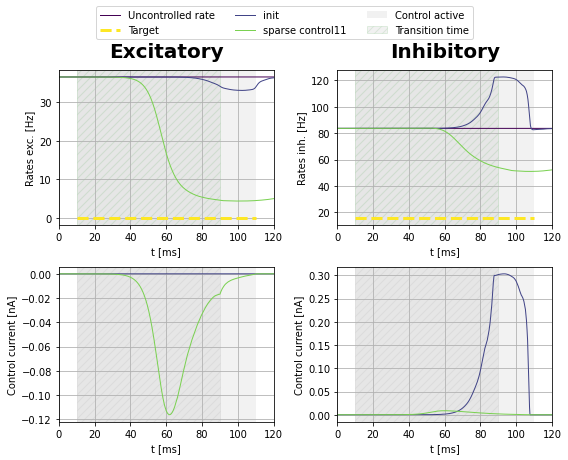

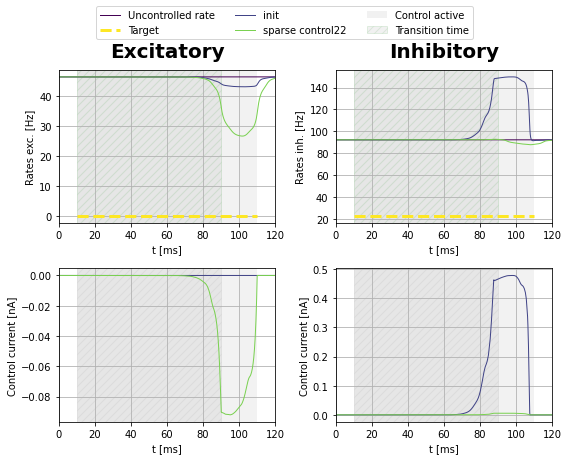

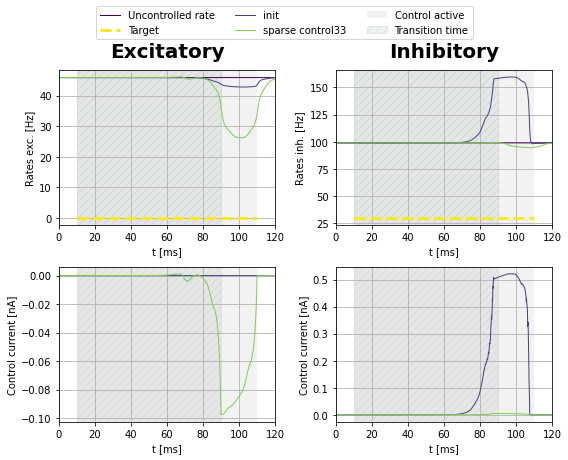

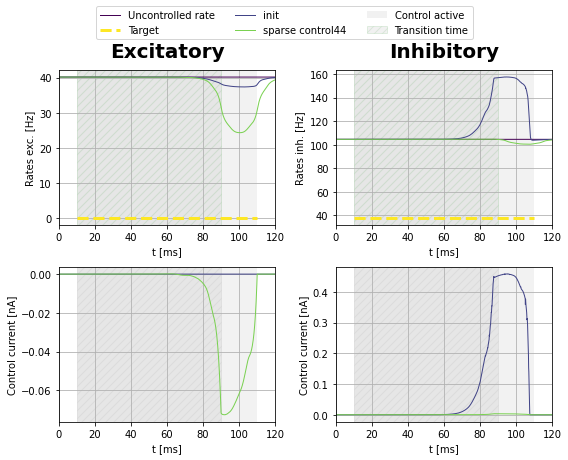

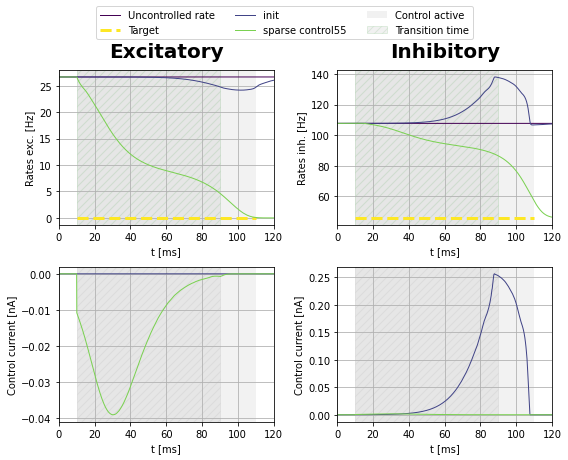

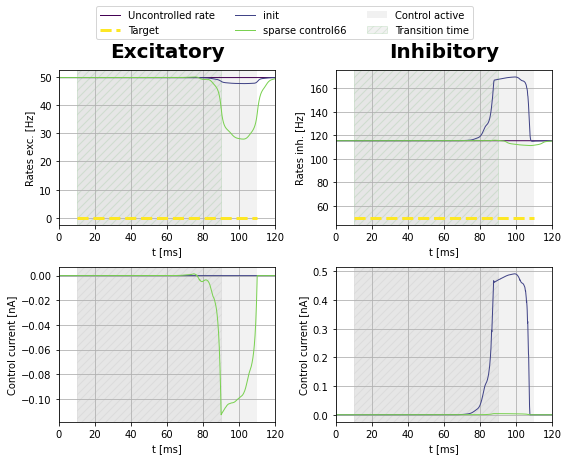

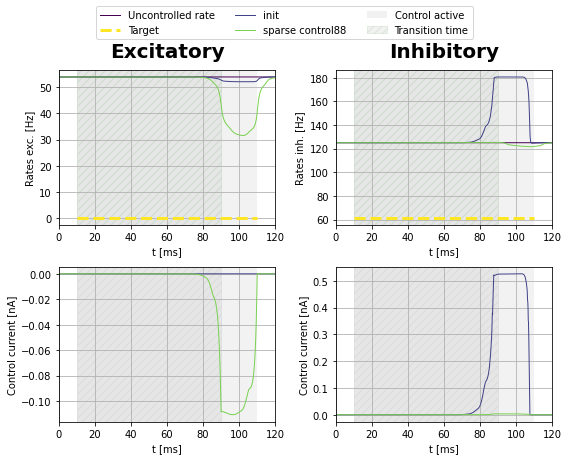

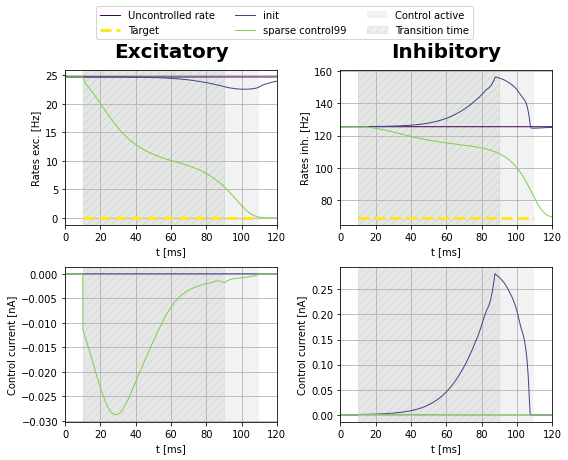

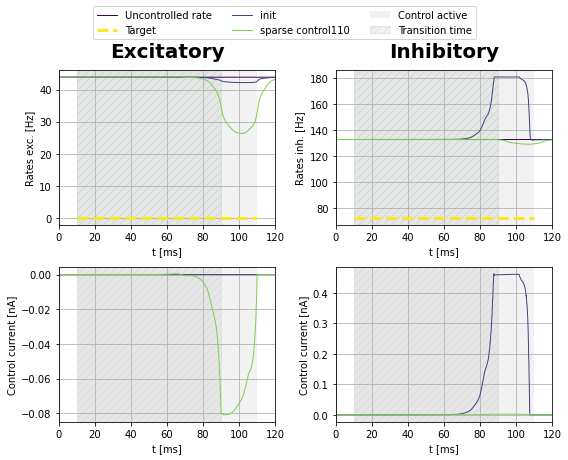

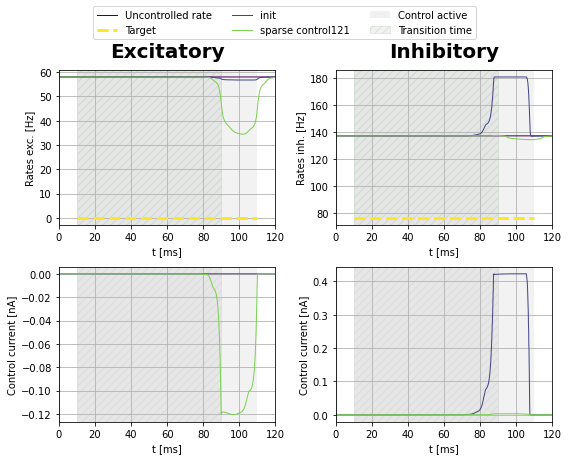

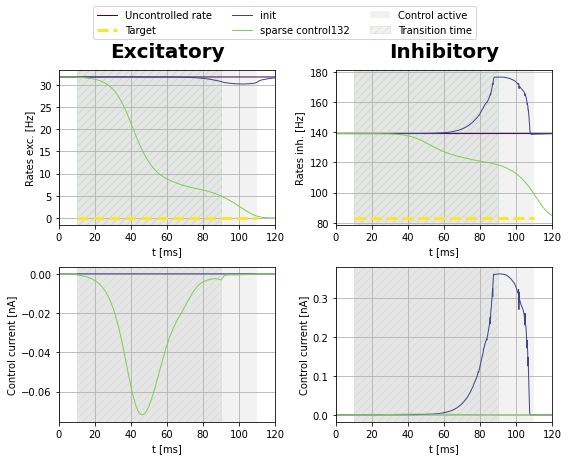

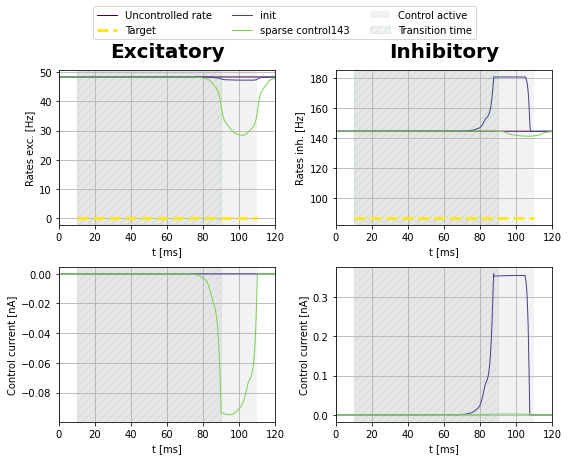

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5039.792992635674
set cost params:  1.0 5039.792992635674 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13292.70429723285
Gradient descend method:  None
RUN  1 , total integrated cost =  12501.985555598794
RUN  2 , total integrated cost =  9408.723321078549
RUN  3 , total integrated cost =  9342.329245400644
RUN  4 , total integrated cost =  9306.182123024675
RUN  5 , total integrated cost =  9305.673820323154
RUN  6 , total integrated cost =  9305.673820323143


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  9305.673820323143
Control only changes marginally.
RUN  7 , total integrated cost =  9305.673820323143
Improved over  7  iterations in  1.0396423488855362  seconds by  29.994126008954325  percent.
Problem in initial value trasfer:  Vmean_exc -56.6421357121852 -56.642947373072744
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  4768.736100962864
set cost params:  1.0 4768.736100962864 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16847.640065771273
Gradient descend method:  None
RUN  1 , total integrated cost =  16171.834192884577
RUN  2 , total integrated cost =  16170.195304832994


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  16170.19530483298
RUN  4 , total integrated cost =  16170.19530483298
Control only changes marginally.
RUN  4 , total integrated cost =  16170.19530483298
Improved over  4  iterations in  0.685473745688796  seconds by  4.021006848992656  percent.
Problem in initial value trasfer:  Vmean_exc -56.68073546719917 -56.68190621170267
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  4946.115943481114
set cost params:  1.0 4946.115943481114 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16685.480481782884
Gradient descend method:  None
RUN  1 , total integrated cost =  15898.521085054956
RUN  2 , total integrated cost =  15895.815993590528
RUN  3 , total integrated cost =  15895.815988840828
RUN  4 , total integrated cost =  15895.815988838487
RUN  5 , total integrated cost =  15895.815988838483


...

RUN  3 , total integrated cost =  19044.534437682625
Control only changes marginally.
RUN  3 , total integrated cost =  19044.534437682625
Improved over  3  iterations in  0.7433642726391554  seconds by  9.040043552488441e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.69254506784419 -56.69257843904494
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  120452.02023564027
set cost params:  1.0 120452.02023564027 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33312.96813644193
Gradient descend method:  None
RUN  1 , total integrated cost =  33312.94025776858
RUN  2 , total integrated cost =  33312.94025343289
RUN  3 , total integrated cost =  33312.94025343288
RUN  4 , total integrated cost =  33312.94025343287


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  33312.94025343287
Control only changes marginally.
RUN  5 , total integrated cost =  33312.94025343287
Improved over  5  iterations in  0.9904123451560736  seconds by  8.370016428216331e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.703591138630244 -56.70357798280581
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
no convergence
weight =  141356.37270210066
set cost params:  1.0 141356.37270210066 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23208.91792243924
Gradient descend method:  None
RUN  1 , total integrated cost =  23208.898327669125
RUN  2 , total integrated cost =  23208.898302617123
RUN  3 , total integrated cost =  23208.89830261709


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  23208.89830261709
Control only changes marginally.
RUN  4 , total integrated cost =  23208.89830261709
Improved over  4  iterations in  0.8016755431890488  seconds by  8.453570397648491e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.700210481115256 -56.70023422396357
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [True, True], [False, False], [True, True], [False, False], [False, False], [True, True], [False, False]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13059.134740452604
Gradient descend method:  None
RUN  1 , total integrated cost =  9189.141843139663
RUN  2 , total integrated cost =  9088.044809018887
RUN  3 , total integrated cost =  9086.70652484457
RUN  4 , total integrated cost =  9086.463942857452
RUN  5 , total integrated cost =  9086.28628546843
RUN  6 , total integrated cost =  9086.127278921485
RUN  7 , total integrated cost =  9086.019689084524
RUN  8 , total integrated cost =  9085.91395725467
RUN  9 , total integrated cost =  9085.824763690363
RUN  10 , total integrated cost =  9085.76152380322
RUN  11 , total integrated cost =  9085.712084222214
RUN  12 , total integrated cost =  9085.671815493302
RUN  13 , total integrated cost =  9085.649825894889
RUN  14 , total integrated cost =  9085.62336123187
RUN  15 , total integrated cost =  9085.61551087366
RUN  16 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  234 , total integrated cost =  9084.85262280059
Improved over  234  iterations in  9.068608777597547  seconds by  30.432966629412945  percent.
Problem in initial value trasfer:  Vmean_exc -56.64390662653823 -56.64448068285079
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21157.619725870813
Gradient descend method:  None
RUN  1 , total integrated cost =  17725.289625446894
RUN  2 , total integrated cost =  17614.96558351264
RUN  3 , total integrated cost =  17610.37620219449
RUN  4 , total integrated cost =  17610.292377170063
RUN  5 , total integrated cost =  17610.27231893575
RUN  6 , total integrated cost =  17610.25408420428
RUN  7 , total integrated cost =  17610.236161807097
RUN  8 , total integrated cost =  17610.220379548704
RUN  9 , total integrated cost =  17610.211811218487
RUN  10 , total integrated cost =  17610.202132671355
RUN  11

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  17610.065940261593
Control only changes marginally.
RUN  31 , total integrated cost =  17610.065940261593
Improved over  31  iterations in  1.226359510794282  seconds by  16.767263196773456  percent.
Problem in initial value trasfer:  Vmean_exc -56.689068319266255 -56.68946245421848
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20670.839987573065
Gradient descend method:  None
RUN  1 , total integrated cost =  17738.767027133006
RUN  2 , total integrated cost =  17607.251418632794
RUN  3 , total integrated cost =  17604.85518809047
RUN  4 , total integrated cost =  17604.716547514876
RUN  5 , total integrated cost =  17604.650130176786
RUN  6 , total integrated cost =  17604.6130617702
RUN  7 , total integrated cost =  17604.58814642984
RUN  8 , total integrated cost =  17604.56195186755
RUN  9 , total integrated cost =  17604.534747904392
RUN  10

...

Control only changes marginally.
RUN  79 , total integrated cost =  31628.914362881376
Improved over  79  iterations in  2.98278327845037  seconds by  4.141818998081774  percent.
Problem in initial value trasfer:  Vmean_exc -56.70394286603051 -56.70392679995451
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  91.53665504126676
Gradient descend method:  None
RUN  1 , total integrated cost =  3.1776598012224793
RUN  2 , total integrated cost =  3.1744394041799375
RUN  3 , total integrated cost =  3.1744378443246246
RUN  4 , total integrated cost =  3.1744378439897267
RUN  5 , total integrated cost =  3.1744378439886387
RUN  6 , total integrated cost =  3.1744378439886356
RUN  7 , total integrated cost =  3.174437843988635


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  3.174437843988635
Control only changes marginally.
RUN  8 , total integrated cost =  3.174437843988635
Improved over  8  iterations in  0.43540672957897186  seconds by  96.53205828576812  percent.
Problem in initial value trasfer:  Vmean_exc -71.76367821514107 -71.8072901297757
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22987.455825274148
Gradient descend method:  None
RUN  1 , total integrated cost =  22047.67558372814
RUN  2 , total integrated cost =  22014.32335769048
RUN  3 , total integrated cost =  22011.20298393187
RUN  4 , total integrated cost =  22009.53675054944
RUN  5 , total integrated cost =  22008.236258011642
RUN  6 , total integrated cost =  22007.22157538275
RUN  7 , total integrated cost =  22006.42956989523
RUN  8 , total integrated cost =  22005.846305422892
RUN  9 , total integrated cost =  22005.500486953795
RUN  10 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  118 , total integrated cost =  21994.81170811186
Improved over  118  iterations in  4.351637715473771  seconds by  4.3181991287217585  percent.
Problem in initial value trasfer:  Vmean_exc -56.69876186418952 -56.6988723990151


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9084.85262280059
Gradient descend method:  None
RUN  1 , total integrated cost =  9084.85262280059
Control only changes marginally.
RUN  1 , total integrated cost =  9084.85262280059
Improved over  1  iterations in  0.12654314562678337  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64390662653823 -56.64448068285079
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17610.065940261593
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  17610.065940261593
Control only changes marginally.
RUN  1 , total integrated cost =  17610.065940261593
Improved over  1  iterations in  0.1264686044305563  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.689068319266255 -56.68946245421848
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17604.411432959983
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  31628.914362881376
Control only changes marginally.
RUN  1 , total integrated cost =  31628.914362881376
Improved over  1  iterations in  0.12645353190600872  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70394286603051 -56.70392679995451
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.174437843988635
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.174437843988635
Control only changes marginally.
RUN  1 , total integrated cost =  3.174437843988635
Improved over  1  iterations in  0.11851504631340504  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.76367821514107 -71.8072901297757
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21994.81170811186
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21994.81170811186
Control only changes marginally.
RUN  1 , total integrated cost =  21994.81170811186
Improved over  1  iterations in  0.12506684847176075  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69876186418952 -56.6988723990151
--------------- 12
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
c

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
